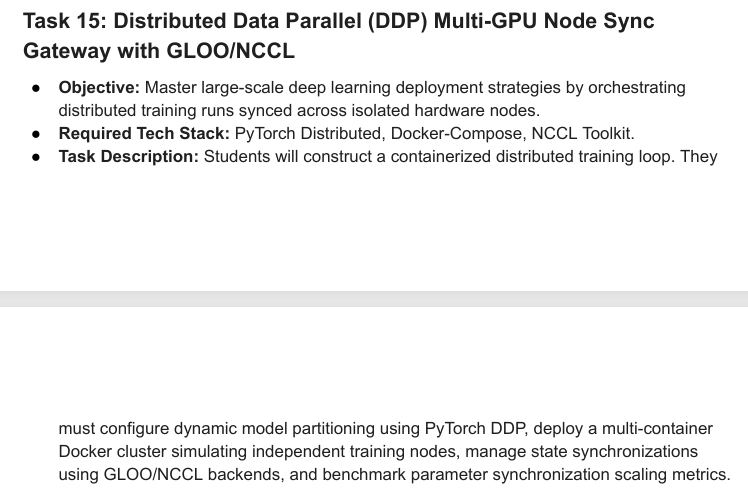

In [5]:
import torch
import torch.nn as nn
import torch.distributed as dist

from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.data.distributed import DistributedSampler

In [6]:
def setup(rank, world_size):

    dist.init_process_group(
        backend="nccl",
        rank=rank,
        world_size=world_size
    )

    torch.cuda.set_device(rank)

In [7]:
class Model(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(10, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.net(x)

In [8]:
def get_data():

    X = torch.randn(1000, 10)
    y = torch.randint(0, 2, (1000,))

    return TensorDataset(X, y)

In [9]:
def train(rank, world_size):

    setup(rank, world_size)

    dataset = get_data()

    sampler = DistributedSampler(
        dataset,
        num_replicas=world_size,
        rank=rank
    )

    loader = DataLoader(
        dataset,
        batch_size=32,
        sampler=sampler
    )

    model = Model().cuda(rank)

    model = DDP(
        model,
        device_ids=[rank]
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(5):

        sampler.set_epoch(epoch)

        for X, y in loader:

            X = X.cuda(rank)
            y = y.cuda(rank)

            output = model(X)

            loss = loss_fn(
                output,
                y
            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

        if rank == 0:
            print(
                f"Epoch {epoch+1} "
                f"Loss: {loss.item():.4f}"
            )

    dist.destroy_process_group()

In [10]:
import torch.multiprocessing as mp

world_size = torch.cuda.device_count()

mp.spawn(
    train,
    args=(world_size,),
    nprocs=world_size
)

In [12]:
print("Distributed training process has completed.")

Distributed training process has completed.
